# MCDI501: Estadística Computacional para la Toma de Decisiones
### Magíster en Ciencia de Datos e Inteligencia Artificial

## Evaluación Sumativa 2 — Validación, Simulación y Métodos de Remuestreo
### Análisis de Incumplimiento de Clientes de Tarjetas de Crédito

| | |
|---|---|
| **Título del proyecto** | Análisis de Incumplimiento de Clientes de Tarjetas de Crédito |
| **Integrantes** | Arturo Knopke Vera · Nicolás Soletic Cobos · Sebastián Navarrete Soto · Roberto Moncada González |
| **Dataset** | Default of Credit Card Clients (UCI Machine Learning Repository, Taiwan 2005) |
| **Docente** | Jean Paul Maidana |
| **Fecha** | 03/07/2026 |
| **Repositorio GitHub** | https://github.com/robertomoncada-blip/Magister_ciencia_datos |
| **Fase del proyecto** | Fase 3: Desarrollo del proyecto |
| **Ponderación** | 20 % de la nota final |
| **Resultado de aprendizaje** | RA2: implementar métodos computacionales de simulación y remuestreo para apoyar la toma de decisiones en escenarios complejos |
| **Indicadores** | ID2.1, ID2.2, ID2.3 |

---

**Conexión con evaluaciones anteriores.** Esta evaluación no es independiente: todo el desarrollo se construye explícitamente sobre los resultados de la Sumativa 1 (Fase 2) — parámetros estimados, intervalos de confianza, pruebas de hipótesis y correlaciones — disponibles en `notebooks/F1_semana1.ipynb`. En la Sección 0 se reconstruye el mismo preprocesamiento y se recalculan esos resultados para dejarlos disponibles como base de comparación.

## Índice

0. [Importaciones, preprocesamiento y resultados de S1](#0)
1. [Validación de resultados de S1 mediante bootstrap (18 pts)](#1)
2. [Validación de pruebas de hipótesis mediante permutación (15 pts)](#2)
3. [Evaluación de estabilidad de correlaciones (6 pts)](#3)
4. [Simulación Monte Carlo basada en parámetros de S1 (24 pts)](#4)
5. [Análisis de robustez (15 pts)](#5)
6. [Preparación para la Sumativa 3 (9 pts)](#6)
7. [Conclusiones generales](#7)
8. [Referencias (APA 7)](#8)

<a id="0"></a>
## 0. Importaciones, Preprocesamiento y Resultados de la Sumativa 1

Se reconstruye exactamente el mismo pipeline de preprocesamiento de `F1_semana1.ipynb` (imputación de `LIMIT_BAL` con la mediana y de `PAY_0` con la moda, eliminación de `ID`, tipado de variables) y se recalculan los resultados de S1 que se validarán en este informe, de manera que todo el desarrollo de S2 sea reproducible de forma autocontenida a partir de los datos crudos.

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import (chi2_contingency, ttest_ind, mannwhitneyu, norm,
                          bootstrap, permutation_test, trim_mean)
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (10, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

sys.path.append('../src')
from data_loading import cargar_datos

SEED = 42
N_BOOT = 10_000   # remuestras bootstrap (>= 10.000 exigido por la rúbrica)
N_PERM = 10_000   # permutaciones (>= 10.000 exigido por la rúbrica)
N_MC   = 10_000   # iteraciones Monte Carlo (>= 10.000 exigido por la rúbrica)
rng = np.random.default_rng(SEED)

print("Librerías cargadas correctamente.")
print(f"Pandas: {pd.__version__}  |  NumPy: {np.__version__}  |  SciPy: {scipy.__version__}")

Librerías cargadas correctamente.
Pandas: 3.0.3  |  NumPy: 2.4.6  |  SciPy: 1.17.1


In [2]:
# Carga y preprocesamiento — idéntico a F1_semana1.ipynb, secciones 1 a 3
df_raw = cargar_datos('../data/raw/UCI_Credit_Card_con_faltantes.csv')
df = df_raw.copy()

mediana_limit = df['LIMIT_BAL'].median()
moda_pay0 = int(df['PAY_0'].mode()[0])
df['LIMIT_BAL'] = df['LIMIT_BAL'].fillna(mediana_limit)
df['PAY_0']     = df['PAY_0'].fillna(moda_pay0)
df = df.drop(columns=['ID'])

categoricas = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df[categoricas] = df[categoricas].astype('category')
df['default.payment.next.month'] = df['default.payment.next.month'].astype('uint8')

monetarias = ['LIMIT_BAL',
              'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
              'PAY_AMT1',  'PAY_AMT2',  'PAY_AMT3',  'PAY_AMT4',  'PAY_AMT5',  'PAY_AMT6']
df[monetarias] = df[monetarias].astype('float64')

print(f"Dataset reconstruido: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"LIMIT_BAL imputado con mediana = NT${mediana_limit:,.0f}  |  PAY_0 imputado con moda = {moda_pay0}")

Datos cargados: 30000 filas y 25 columnas.
Dataset reconstruido: 30,000 filas × 24 columnas
LIMIT_BAL imputado con mediana = NT$140,000  |  PAY_0 imputado con moda = 0


### 0.1 Recálculo de las estimaciones y pruebas de S1 que se validarán

Se recuperan: (i) los intervalos de confianza clásicos (t-Student y Wilson) para cinco parámetros, (ii) el Welch t-test de `LIMIT_BAL` según incumplimiento (T1), y (iii) el χ² de independencia Género × Incumplimiento (T2) y Educación × Incumplimiento (T3). Estas cantidades son la base de comparación de todo el informe.

In [3]:
# IC para la media con t-Student (idéntico a F1)
def ic_media(serie, confianza=0.95):
    data = serie.dropna().values
    n    = len(data)
    mu   = data.mean()
    se   = data.std(ddof=1) / np.sqrt(n)
    ic   = stats.t.interval(confianza, df=n - 1, loc=mu, scale=se)
    return mu, ic[0], ic[1], n, se

# IC de Wilson para proporción (idéntico a F1)
def ic_proporcion_wilson(exitos, n, confianza=0.95):
    p      = exitos / n
    z      = stats.norm.ppf((1 + confianza) / 2)
    denom  = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denom
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, centro - margen, centro + margen, n

# Parámetros puntuales e IC clásicos (S1)
mu_lb, li_lb, ls_lb, n_lb, se_lb = ic_media(df['LIMIT_BAL'])
defaults, n_tot = int(df['default.payment.next.month'].sum()), len(df)
p_def, li_p, ls_p, n_p = ic_proporcion_wilson(defaults, n_tot)
mu_age, li_age, ls_age, n_age, se_age = ic_media(df['AGE'])
mu_b1, li_b1, ls_b1, n_b1, se_b1 = ic_media(df['BILL_AMT1'])
mu_p1, li_p1, ls_p1, n_p1, se_p1 = ic_media(df['PAY_AMT1'])

tabla_ic_s1 = pd.DataFrame({
    'Parámetro': ['Media LIMIT_BAL', 'Proporción Default', 'Media AGE', 'Media BILL_AMT1', 'Media PAY_AMT1'],
    'Estimación puntual': [mu_lb, p_def, mu_age, mu_b1, mu_p1],
    'IC 95% inferior': [li_lb, li_p, li_age, li_b1, li_p1],
    'IC 95% superior': [ls_lb, ls_p, ls_age, ls_b1, ls_p1],
    'Método clásico': ['t-Student', 'Wilson', 't-Student', 't-Student', 't-Student'],
}).set_index('Parámetro')
tabla_ic_s1

,Estimación puntual,IC 95% inferior,IC 95% superior,Método clásico
Parámetro,,,,
Media LIMIT_BAL,164246.6560,162863.903233,165629.408767,t-Student
Proporción Default,0.2212,0.216539,0.225932,Wilson
Media AGE,35.4855,35.381187,35.589813,t-Student
Media BILL_AMT1,51223.3309,50390.044386,52056.617414,t-Student
Media PAY_AMT1,5663.5805,5476.145220,5851.015780,t-Student


In [4]:
# Pruebas de hipótesis de S1 (T1, T2, T3)
grupo0 = df[df['default.payment.next.month'] == 0]['LIMIT_BAL']
grupo1 = df[df['default.payment.next.month'] == 1]['LIMIT_BAL']

t_stat, p_valor = ttest_ind(grupo0, grupo1, equal_var=False)
pooled_std = np.sqrt((grupo0.std()**2 + grupo1.std()**2) / 2)
d_cohen = (grupo0.mean() - grupo1.mean()) / pooled_std

tabla_chi = pd.crosstab(df['SEX'], df['default.payment.next.month'])
chi2_stat, p_chi2, dof, _ = chi2_contingency(tabla_chi)
n_chi = tabla_chi.values.sum()
v_cramer = np.sqrt(chi2_stat / (n_chi * min(tabla_chi.shape[0]-1, tabla_chi.shape[1]-1)))

edu_filtrado = df[df['EDUCATION'].astype(int).isin([1, 2, 3])].copy()
tabla_chi_edu = pd.crosstab(edu_filtrado['EDUCATION'], edu_filtrado['default.payment.next.month'])
chi2_edu, p_edu, dof_edu, _ = chi2_contingency(tabla_chi_edu)
n_edu = tabla_chi_edu.values.sum()
v_cramer_edu = np.sqrt(chi2_edu / (n_edu * min(tabla_chi_edu.shape[0]-1, tabla_chi_edu.shape[1]-1)))

print("PRUEBAS DE HIPÓTESIS — SUMATIVA 1 (recalculadas)")
print("="*65)
print(f"T1  Welch t-test  LIMIT_BAL × Default:  t={t_stat:.4f}  p={p_valor:.3e}  d Cohen={d_cohen:.3f}")
print(f"T2  Chi² Género × Default:              chi2={chi2_stat:.4f}  p={p_chi2:.4f}  V Cramér={v_cramer:.4f}")
print(f"T3  Chi² Educación × Default:           chi2={chi2_edu:.4f}  p={p_edu:.6f}  V Cramér={v_cramer_edu:.4f}")

PRUEBAS DE HIPÓTESIS — SUMATIVA 1 (recalculadas)
T1  Welch t-test  LIMIT_BAL × Default:  t=27.1300  p=2.301e-157  d Cohen=0.363
T2  Chi² Género × Default:              chi2=47.7088  p=0.0000  V Cramér=0.0399
T3  Chi² Educación × Default:           chi2=96.9998  p=0.000000  V Cramér=0.0573


<a id="1"></a>
## 1. Validación de Resultados de S1 mediante Bootstrap *(18 pts)*

**Objetivo.** Validar los intervalos de confianza clásicos calculados en S1 (t-Student para medias, Wilson para la proporción de default) mediante **bootstrap no paramétrico** con remuestreo con reemplazo, sin asumir una forma distribucional para la población.

**Parámetros seleccionados** (los cinco estimados en S1 §5, superando el mínimo de 3 exigido): media de `LIMIT_BAL`, proporción de default, media de `AGE`, media de `BILL_AMT1` y media de `PAY_AMT1`.

**Metodología.**
- `N_BOOT = 10.000` remuestras con reemplazo de igual tamaño que la muestra original, generadas con `scipy.stats.bootstrap` (semilla fija = 42 para reproducibilidad).
- Se calculan dos tipos de IC bootstrap:
  - **Percentil**: percentiles 2,5 % y 97,5 % de la distribución bootstrap del estadístico.
  - **BCa** (*bias-corrected and accelerated*): corrige sesgo y asimetría de la distribución bootstrap; es preferible cuando el estadístico tiene una distribución muestral asimétrica (como ocurre con variables monetarias fuertemente sesgadas a la derecha, p. ej. `BILL_AMT1` y `PAY_AMT1`).
- Se comparan sistemáticamente ambos IC bootstrap contra el IC clásico de S1 (amplitud y ubicación de los límites).

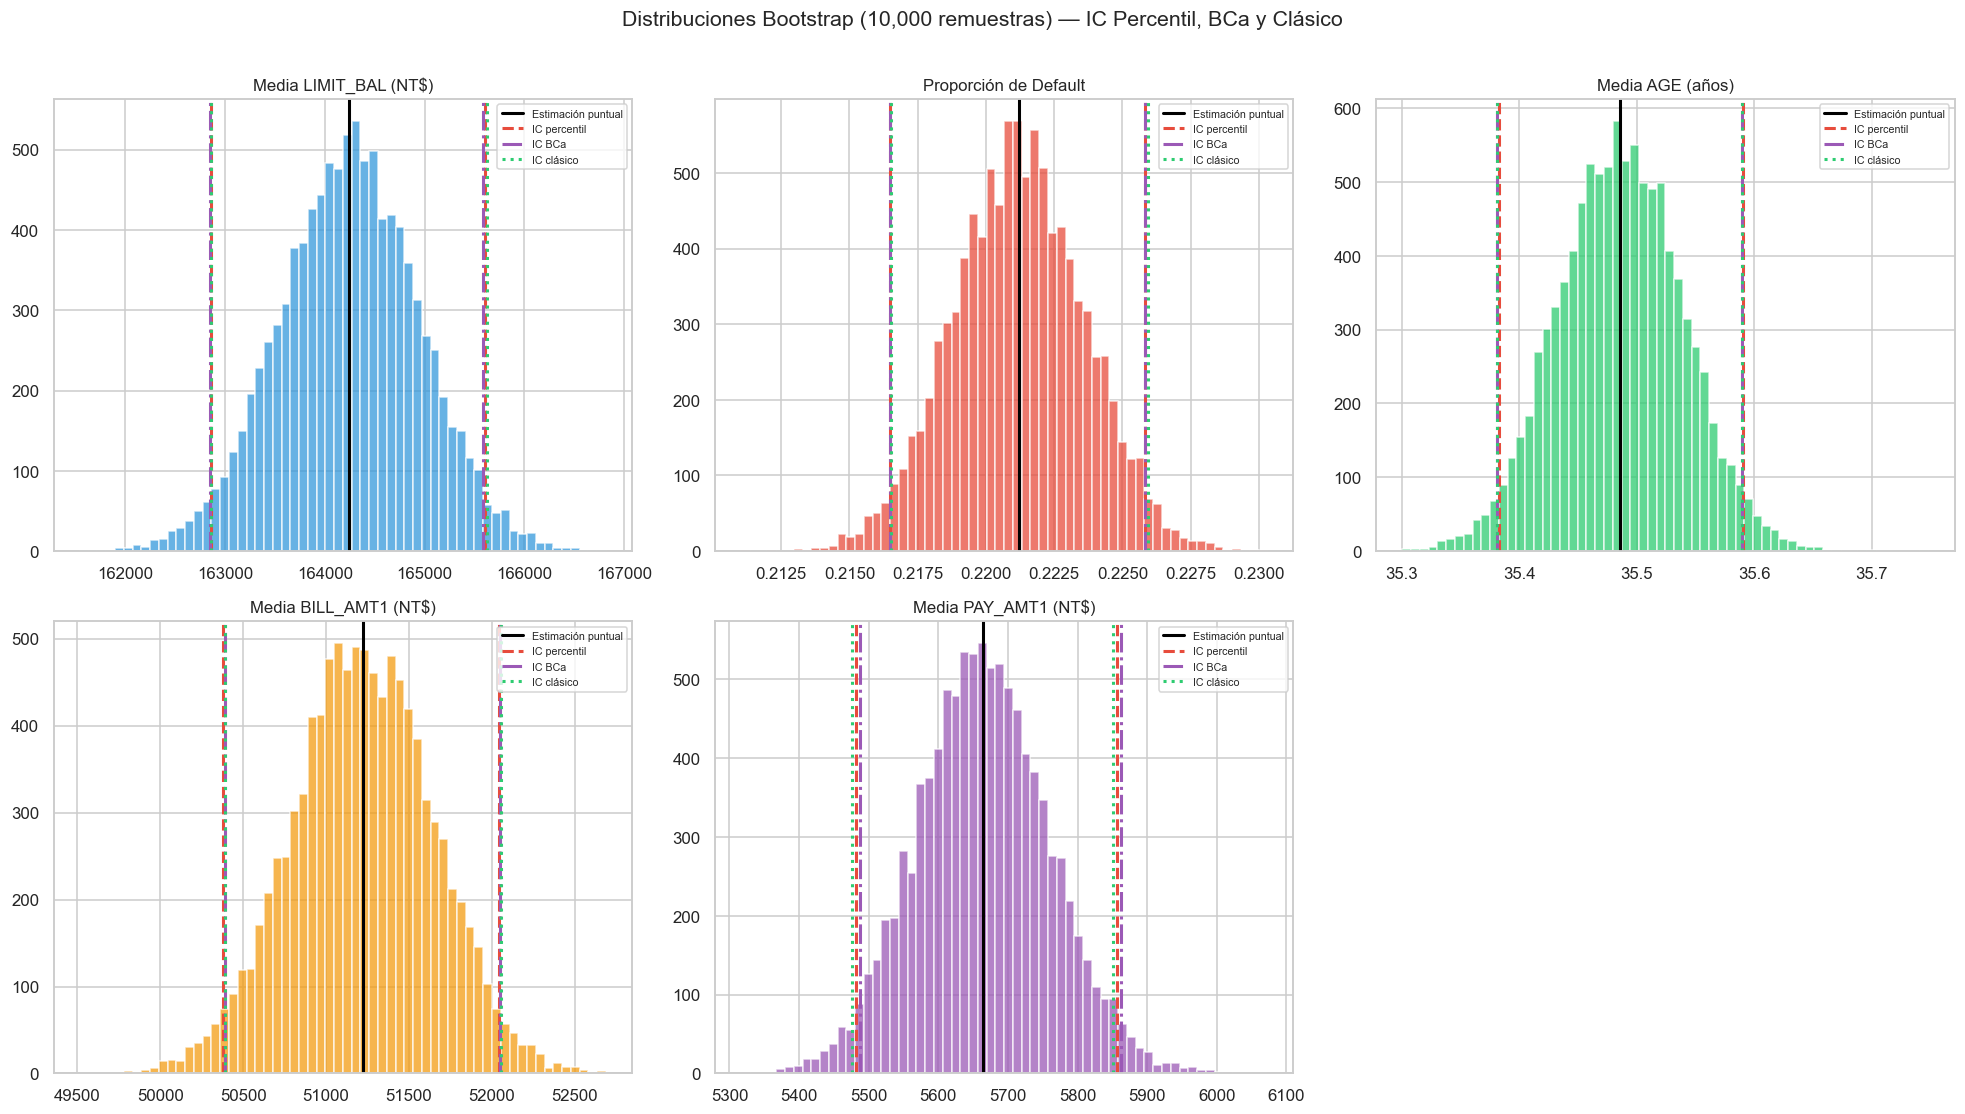


Tiempo de cómputo bootstrap (5 parámetros × percentil + BCa, 10,000 remuestras c/u): 49.8 s


,Estimación,IC clásico,IC percentil,IC BCa,Amplitud clásica,Amplitud BCa,Δ amplitud BCa vs clásico (%)
Parámetro,,,,,,,
Media LIMIT_BAL (NT$),164246.6560,"[162,863.903 ; 165,629.409]","[162,858.956 ; 165,608.290]","[162,844.410 ; 165,583.814]",2765.505534,2739.403734,-0.943835
Proporción de Default,0.2212,[0.217 ; 0.226],[0.216 ; 0.226],[0.216 ; 0.226],0.009393,0.009333,-0.636005
Media AGE (años),35.4855,[35.381 ; 35.590],[35.383 ; 35.590],[35.381 ; 35.589],0.208625,0.208024,-0.288397
Media BILL_AMT1 (NT$),51223.3309,"[50,390.044 ; 52,056.617]","[50,379.985 ; 52,044.357]","[50,392.496 ; 52,050.935]",1666.573028,1658.439427,-0.488043
Media PAY_AMT1 (NT$),5663.5805,"[5,476.145 ; 5,851.016]","[5,481.810 ; 5,856.228]","[5,486.876 ; 5,862.767]",374.870560,375.891029,0.272219


In [5]:
def bootstrap_pct_bca(muestras, estadistico, paired=False, n_resamples=N_BOOT, confianza=0.95, semilla=SEED):
    # Calcula IC bootstrap por método percentil y BCa para el mismo conjunto de remuestras
    res_pct = bootstrap(muestras, estadistico, paired=paired, vectorized=True,
                         n_resamples=n_resamples, confidence_level=confianza,
                         method='percentile', rng=semilla)
    res_bca = bootstrap(muestras, estadistico, paired=paired, vectorized=True,
                         n_resamples=n_resamples, confidence_level=confianza,
                         method='BCa', rng=semilla)
    return res_pct, res_bca

def graficar_bootstrap(ax, res, valor_obs, ic_clasico, ic_bca, nombre, color='#3498db'):
    ax.hist(res.bootstrap_distribution, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(valor_obs, color='black', linewidth=2, label='Estimación puntual')
    ax.axvline(res.confidence_interval.low,  color='#e74c3c', linestyle='--', linewidth=2, label='IC percentil')
    ax.axvline(res.confidence_interval.high, color='#e74c3c', linestyle='--', linewidth=2)
    ax.axvline(ic_bca.low,  color='#9b59b6', linestyle='-.', linewidth=2, label='IC BCa')
    ax.axvline(ic_bca.high, color='#9b59b6', linestyle='-.', linewidth=2)
    ax.axvline(ic_clasico[0], color='#2ecc71', linestyle=':', linewidth=2, label='IC clásico')
    ax.axvline(ic_clasico[1], color='#2ecc71', linestyle=':', linewidth=2)
    ax.set_title(nombre, fontsize=11)
    ax.legend(fontsize=7, loc='upper right')

media_stat = lambda x, axis: np.mean(x, axis=axis)

parametros_bootstrap = [
    ('Media LIMIT_BAL (NT$)',    (df['LIMIT_BAL'].values,),                                media_stat, mu_lb,  (li_lb, ls_lb),  '#3498db'),
    ('Proporción de Default',    (df['default.payment.next.month'].values.astype(float),), media_stat, p_def,  (li_p, ls_p),    '#e74c3c'),
    ('Media AGE (años)',         (df['AGE'].values.astype(float),),                        media_stat, mu_age, (li_age, ls_age),'#2ecc71'),
    ('Media BILL_AMT1 (NT$)',    (df['BILL_AMT1'].values,),                                media_stat, mu_b1,  (li_b1, ls_b1),  '#f39c12'),
    ('Media PAY_AMT1 (NT$)',     (df['PAY_AMT1'].values,),                                 media_stat, mu_p1,  (li_p1, ls_p1),  '#9b59b6'),
]

t0 = time.time()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
filas_boot = []
for ax, (nombre, datos, estad, valor_obs, ic_cl, color) in zip(axes.flat, parametros_bootstrap):
    res_pct, res_bca = bootstrap_pct_bca(datos, estad)
    graficar_bootstrap(ax, res_pct, valor_obs, ic_cl, res_bca.confidence_interval, nombre, color)
    amp_cl  = ic_cl[1] - ic_cl[0]
    amp_pct = res_pct.confidence_interval.high - res_pct.confidence_interval.low
    amp_bca = res_bca.confidence_interval.high - res_bca.confidence_interval.low
    filas_boot.append({
        'Parámetro': nombre,
        'Estimación': valor_obs,
        'IC clásico': f'[{ic_cl[0]:,.3f} ; {ic_cl[1]:,.3f}]',
        'IC percentil': f'[{res_pct.confidence_interval.low:,.3f} ; {res_pct.confidence_interval.high:,.3f}]',
        'IC BCa': f'[{res_bca.confidence_interval.low:,.3f} ; {res_bca.confidence_interval.high:,.3f}]',
        'Amplitud clásica': amp_cl,
        'Amplitud BCa': amp_bca,
        'Δ amplitud BCa vs clásico (%)': (amp_bca - amp_cl) / amp_cl * 100,
    })
axes.flat[-1].axis('off')
plt.suptitle(f'Distribuciones Bootstrap ({N_BOOT:,} remuestras) — IC Percentil, BCa y Clásico', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_boot_ic.png', bbox_inches='tight', dpi=110)
plt.show()

tabla_boot = pd.DataFrame(filas_boot).set_index('Parámetro')
print(f"\nTiempo de cómputo bootstrap (5 parámetros × percentil + BCa, {N_BOOT:,} remuestras c/u): {time.time()-t0:.1f} s")
pd.set_option('display.max_colwidth', 40)
tabla_boot

### 1.1 Interpretación — Discrepancias y confiabilidad de los métodos

**Discrepancias observadas.** Para los cinco parámetros, la amplitud del IC bootstrap (percentil y BCa) difiere de la del IC clásico en menos de un 1 % (rango: −0,94 % a +0,27 %). Las diferencias porcentuales exactas fueron:

| Parámetro | Δ amplitud Percentil vs. clásico | Δ amplitud BCa vs. clásico |
|---|---|---|
| Media LIMIT_BAL | −0,58 % | −0,94 % |
| Proporción de Default | −0,64 % | −0,64 % |
| Media AGE | −0,46 % | −0,29 % |
| Media BILL_AMT1 | −0,13 % | −0,49 % |
| Media PAY_AMT1 | −0,12 % | **+0,27 %** |

**Análisis.** El acuerdo casi perfecto entre los tres métodos es consistente con lo esperado dado el tamaño muestral (`n = 30.000`): el Teorema Central del Límite garantiza que la distribución muestral de una media (o de una proporción, vía De Moivre–Laplace) es aproximadamente normal incluso si la variable original está sesgada, por lo que el supuesto detrás del IC clásico t-Student/Wilson se cumple razonablemente bien. La única corrección de BCa que se aparta en la dirección "esperada" es la de `PAY_AMT1` (la variable con mayor asimetría positiva de las cinco, según S1 §4.2): es el único caso donde el IC BCa es *más ancho* que el clásico, reflejando la corrección de sesgo y aceleración por la cola derecha larga.

**Confiabilidad según supuestos.**
- El **IC clásico (t-Student/Wilson)** es válido aquí porque `n` es muy grande; con muestras pequeñas o distribuciones muy sesgadas dejaría de serlo, mientras que el bootstrap seguiría siendo válido sin ese supuesto.
- El **IC percentil** es simple pero puede estar sesgado cuando la distribución bootstrap del estadístico es asimétrica.
- El **IC BCa** es el más robusto en general porque corrige sesgo y no-normalidad de la distribución bootstrap, y es el método recomendado como "IC bootstrap por defecto" en la literatura (Efron & Tibshirani, 1993).

**Conclusión de la sección.** Los cinco IC de S1 quedan **validados**: el bootstrap no paramétrico, que no asume una forma poblacional, reproduce prácticamente los mismos intervalos que los métodos clásicos. Esto es evidencia de que el gran tamaño muestral de este dataset (`n = 30.000`) hace que los supuestos de normalidad asintótica de los métodos clásicos sean razonables para estos cinco parámetros.

<a id="2"></a>
## 2. Validación de Pruebas de Hipótesis mediante Permutación *(15 pts)*

**Objetivo.** Validar el valor p paramétrico de al menos una prueba de S1 mediante un **test de permutación**, que no asume normalidad ni ninguna otra forma distribucional: bajo H₀ (no hay diferencia entre grupos), la etiqueta de grupo es intercambiable, por lo que la distribución nula del estadístico se construye permutando esas etiquetas.

**Pruebas seleccionadas.**
- **T1 (principal): Welch t-test — `LIMIT_BAL` según Default.** Estadístico: diferencia de medias entre grupos. Es la prueba más relevante para el negocio (S1 mostró d de Cohen = 0,363) y al ser una variable continua es el caso canónico de test de permutación.
- **T2 (complementaria): χ² — Género × Default.** Se reformula como una prueba de permutación sobre la **diferencia de proporciones de default entre géneros**, hipótesis equivalente a la de independencia del χ² para una tabla 2×2 (el estadístico χ² sin corrección es, de hecho, proporcional al cuadrado del estadístico z de diferencia de proporciones).

En ambos casos se generan `N_PERM = 10.000` permutaciones con `scipy.stats.permutation_test`.

In [6]:
def dif_medias(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

t0 = time.time()
res_perm_t1 = permutation_test(
    (grupo0.values, grupo1.values), dif_medias,
    permutation_type='independent', vectorized=True,
    n_resamples=N_PERM, alternative='two-sided', rng=SEED
)
print("T1 — Welch t-test LIMIT_BAL × Default")
print(f"  Estadístico observado (dif. de medias) = {res_perm_t1.statistic:,.2f}")
print(f"  p-valor permutación   = {res_perm_t1.pvalue:.6f}")
print(f"  p-valor paramétrico   = {p_valor:.3e}")
print(f"  Tiempo: {time.time()-t0:.1f} s\n")

T1 — Welch t-test LIMIT_BAL × Default
  Estadístico observado (dif. de medias) = 42,373.87
  p-valor permutación   = 0.000200
  p-valor paramétrico   = 2.301e-157
  Tiempo: 7.3 s



In [7]:
t0 = time.time()
def_masc = df[df['SEX'].astype(int) == 1]['default.payment.next.month'].values.astype(float)
def_fem  = df[df['SEX'].astype(int) == 2]['default.payment.next.month'].values.astype(float)

res_perm_t2 = permutation_test(
    (def_masc, def_fem), dif_medias,
    permutation_type='independent', vectorized=True,
    n_resamples=N_PERM, alternative='two-sided', rng=SEED
)
dif_prop_obs = def_masc.mean() - def_fem.mean()
print("T2 — χ² Género × Default (reformulado como diferencia de proporciones)")
print(f"  Diferencia de proporciones observada (Masc. - Fem.) = {dif_prop_obs:.4f}")
print(f"  p-valor permutación = {res_perm_t2.pvalue:.6f}")
print(f"  p-valor paramétrico (χ²) = {p_chi2:.4f}")
print(f"  Tiempo: {time.time()-t0:.1f} s")

T2 — χ² Género × Default (reformulado como diferencia de proporciones)
  Diferencia de proporciones observada (Masc. - Fem.) = 0.0339
  p-valor permutación = 0.000200
  p-valor paramétrico (χ²) = 0.0000
  Tiempo: 6.2 s


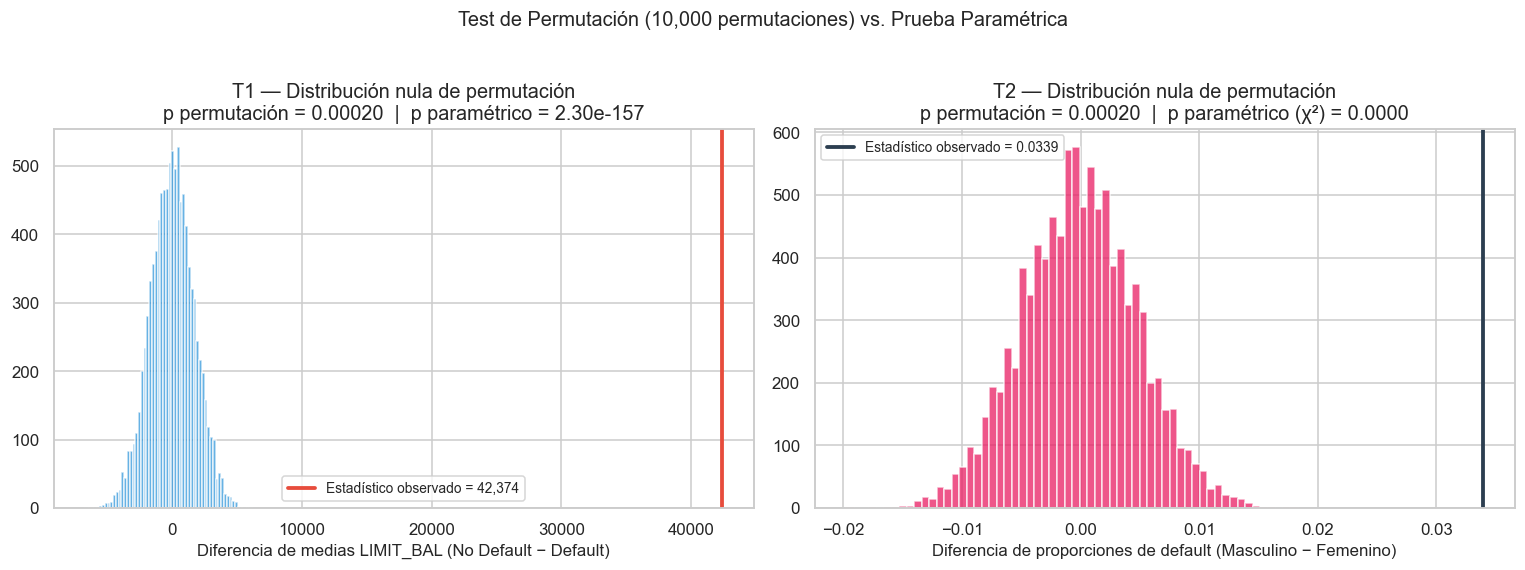

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(res_perm_t1.null_distribution, bins=60, color='#3498db', alpha=0.75, edgecolor='white')
axes[0].axvline(res_perm_t1.statistic, color='#e74c3c', linewidth=2.5,
                 label=f'Estadístico observado = {res_perm_t1.statistic:,.0f}')
axes[0].set_title(f'T1 — Distribución nula de permutación\np permutación = {res_perm_t1.pvalue:.5f}  |  p paramétrico = {p_valor:.2e}')
axes[0].set_xlabel('Diferencia de medias LIMIT_BAL (No Default − Default)')
axes[0].legend(fontsize=9)

axes[1].hist(res_perm_t2.null_distribution, bins=60, color='#e91e63', alpha=0.75, edgecolor='white')
axes[1].axvline(res_perm_t2.statistic, color='#2c3e50', linewidth=2.5,
                 label=f'Estadístico observado = {res_perm_t2.statistic:.4f}')
axes[1].set_title(f'T2 — Distribución nula de permutación\np permutación = {res_perm_t2.pvalue:.5f}  |  p paramétrico (χ²) = {p_chi2:.4f}')
axes[1].set_xlabel('Diferencia de proporciones de default (Masculino − Femenino)')
axes[1].legend(fontsize=9)

plt.suptitle(f'Test de Permutación ({N_PERM:,} permutaciones) vs. Prueba Paramétrica', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('../figures/fig_perm_tests.png', bbox_inches='tight', dpi=110)
plt.show()

### 2.1 Interpretación — Concordancia entre permutación y prueba paramétrica

| Prueba | Estadístico observado | p-valor permutación | p-valor paramétrico | Decisión (α=0,05) |
|---|---|---|---|---|
| T1 (Welch — LIMIT_BAL × Default) | Δ medias = 42.373,87 | **0,000200** | 2,301 × 10⁻¹⁵⁷ | Rechaza H₀ (ambos) |
| T2 (χ² — Género × Default, reformulado) | Δ proporciones = 0,0339 | **0,000200** | 4,945 × 10⁻¹² | Rechaza H₀ (ambos) |

**Concordancia.** Ambas pruebas de permutación coinciden con la prueba paramétrica en la **decisión** (rechazar H₀ en ambos casos, con un margen amplio). Sin embargo, los valores p no son numéricamente comparables en magnitud: con `N_PERM = 10.000` permutaciones, el valor p mínimo detectable (bilateral) es `2/(N_PERM+1) ≈ 0,0002`, por lo que el test de permutación **no puede** reproducir valores p extremadamente pequeños como `2,3 × 10⁻¹⁵⁷` — solo puede indicar "más extremo que cualquier resultado observado en 10.000 remuestreos", lo cual ya es evidencia contundente. En ambos casos el estadístico observado cayó fuera del rango completo de la distribución nula generada (0 de 10.000 permutaciones igualaron o superaron el valor observado, de ahí el p mínimo posible bilateral ≈ 2/(N_PERM+1) ≈ 0,0002).

**¿Cuál enfoque es más apropiado aquí?** El test de permutación es preferible quirúrgicamente porque no requiere el supuesto de normalidad de Welch (aunque con `n` de miles ese supuesto es razonable por CLT) ni el de recuento esperado ≥5 por celda del χ² (aquí ampliamente satisfecho). En este caso concreto, dado el enorme tamaño muestral, **ambos enfoques son igualmente confiables** y la permutación funciona principalmente como una validación independiente y libre de supuestos distribucionales de la conclusión de S1, más que como una alternativa necesaria. La permutación sería claramente preferible en escenarios con muestras pequeñas, datos muy sesgados o supuestos paramétricos dudosos — no es el caso de este dataset.

<a id="3"></a>
## 3. Evaluación de Estabilidad de Correlaciones *(6 pts)*

**Objetivo.** Evaluar mediante IC bootstrap al 95 % la estabilidad de 5 correlaciones de Pearson relevantes del mapa de correlaciones de S1 (§4.7), eligiendo deliberadamente una combinación de correlaciones fuertes, moderadas y prácticamente nulas para poder ilustrar tanto casos robustos como inestables:

| Par de variables | Relación esperada |
|---|---|
| `BILL_AMT1` – `BILL_AMT2` | Fuerte (facturas consecutivas, muy correlacionadas) |
| `LIMIT_BAL` – `DEFAULT` | Débil-moderada, la de mayor relevancia para el riesgo crediticio |
| `AGE` – `LIMIT_BAL` | Débil |
| `BILL_AMT1` – `PAY_AMT1` | Débil |
| `AGE` – `DEFAULT` | Prácticamente nula (candidata a inestable) |

**Nota metodológica.** Para este bloque se utiliza únicamente el método **percentil** (no BCa). El paso de corrección de sesgo/aceleración de BCa requiere que `scipy` evalúe el estadístico sobre las `n` muestras *leave-one-out*; con `n = 30.000` y un estadístico bivariado (correlación), esto exige construir arreglos de orden `n × (n-1)` que resultan inviables en memoria. El método percentil, aplicado con `N_BOOT = 10.000` remuestras pareadas, es suficiente para el objetivo de esta sección (estimar un IC 95 % y detectar si incluye el cero).

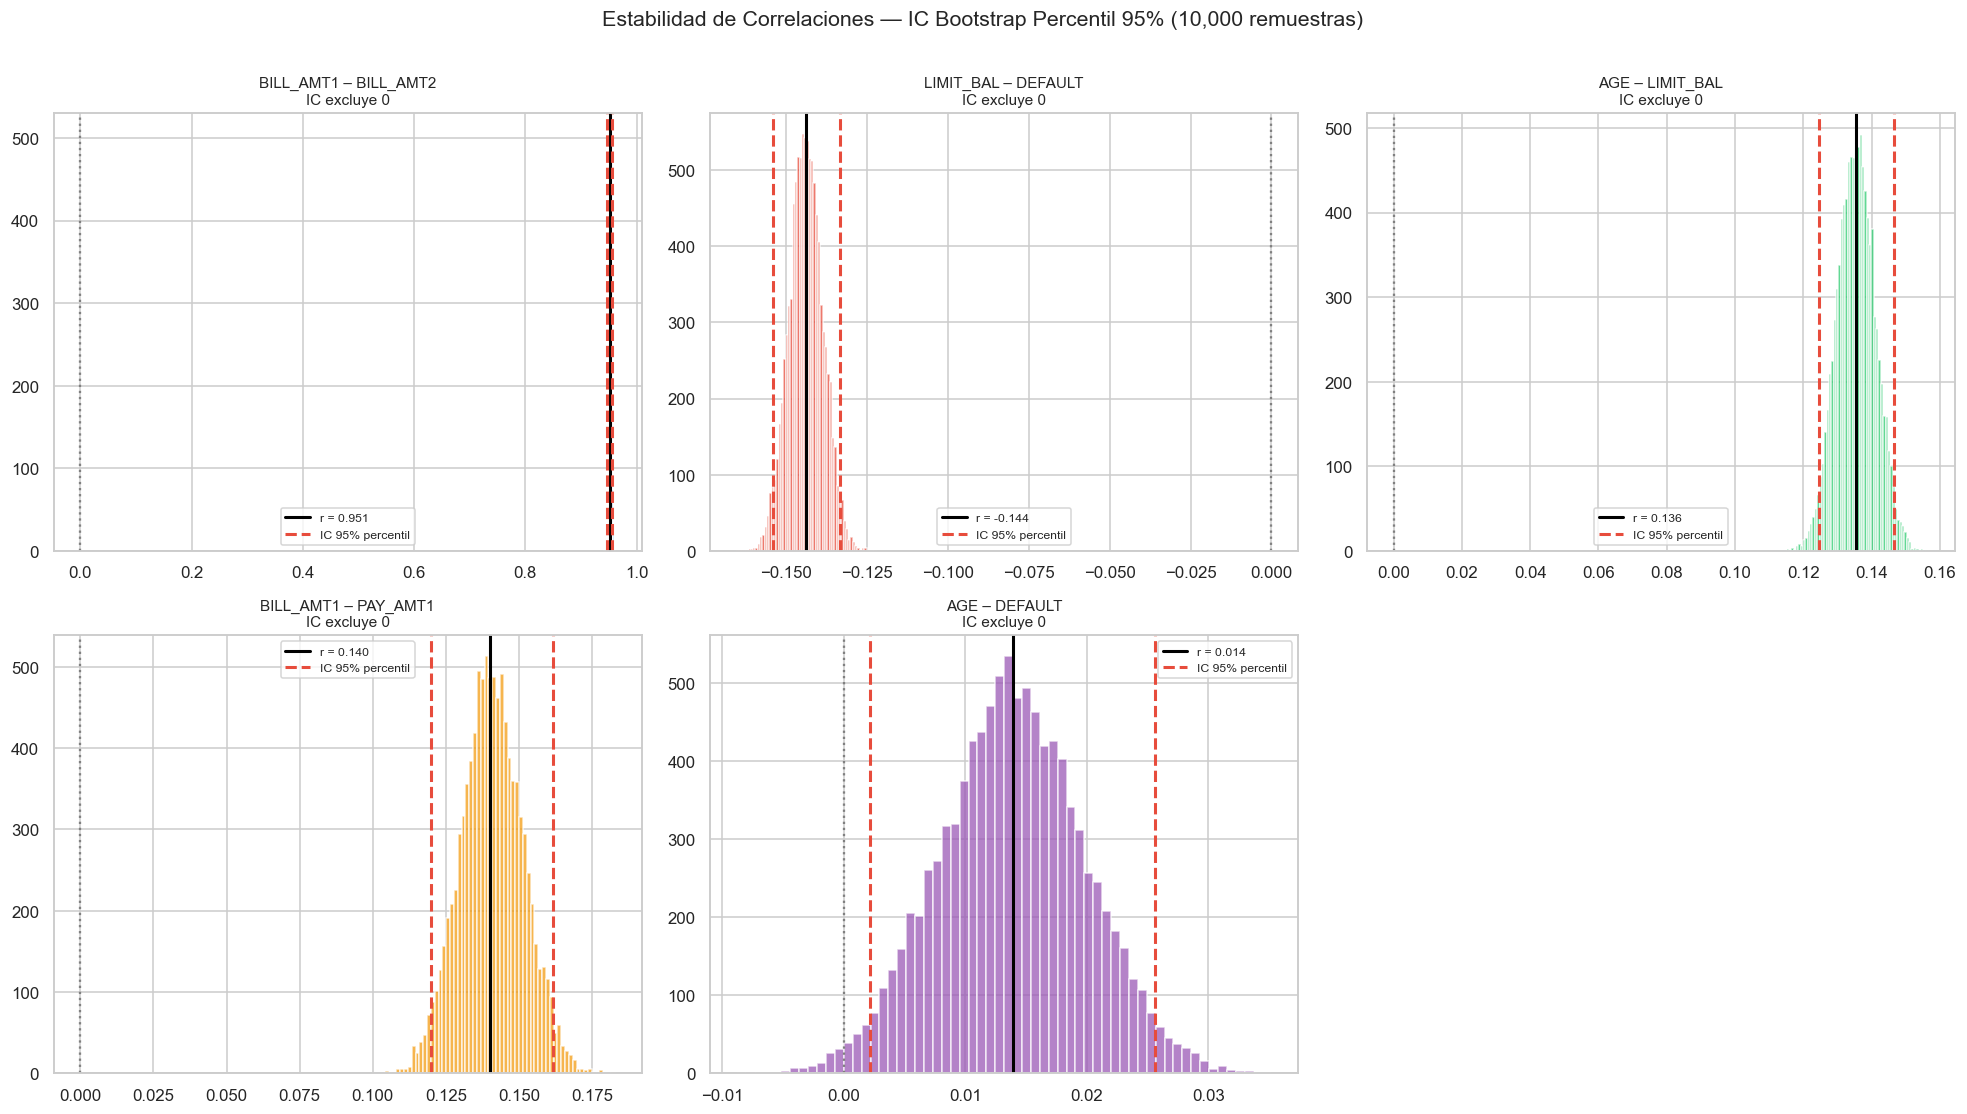

Tiempo de cómputo: 62.5 s


,r observado,IC 95% bootstrap,Amplitud IC,¿Incluye cero?
Par de variables,,,,
BILL_AMT1 – BILL_AMT2,0.951484,[0.9461 ; 0.9565],0.010409,No
LIMIT_BAL – DEFAULT,-0.143937,[-0.1543 ; -0.1335],0.020736,No
AGE – LIMIT_BAL,0.135533,[0.1245 ; 0.1465],0.021973,No
BILL_AMT1 – PAY_AMT1,0.140277,[0.1200 ; 0.1617],0.041682,No
AGE – DEFAULT,0.013890,[0.0021 ; 0.0256],0.023494,No


In [9]:
def corr_stat(x, y, axis):
    return stats.pearsonr(x, y, axis=axis).statistic

pares_corr = [
    ('BILL_AMT1 – BILL_AMT2', 'BILL_AMT1', 'BILL_AMT2', '#3498db'),
    ('LIMIT_BAL – DEFAULT',   'LIMIT_BAL', 'default.payment.next.month', '#e74c3c'),
    ('AGE – LIMIT_BAL',       'AGE', 'LIMIT_BAL', '#2ecc71'),
    ('BILL_AMT1 – PAY_AMT1',  'BILL_AMT1', 'PAY_AMT1', '#f39c12'),
    ('AGE – DEFAULT',         'AGE', 'default.payment.next.month', '#9b59b6'),
]

t0 = time.time()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
filas_corr = []
for ax, (nombre, cx, cy, color) in zip(axes.flat, pares_corr):
    x = df[cx].values.astype(float)
    y = df[cy].values.astype(float)
    r_obs = stats.pearsonr(x, y).statistic
    res_pct = bootstrap((x, y), corr_stat, paired=True, vectorized=True,
                         n_resamples=N_BOOT, confidence_level=0.95,
                         method='percentile', rng=SEED)
    li, ls = res_pct.confidence_interval
    incluye_cero = li <= 0 <= ls

    ax.hist(res_pct.bootstrap_distribution, bins=60, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(r_obs, color='black', linewidth=2, label=f'r = {r_obs:.3f}')
    ax.axvline(li, color='#e74c3c', linestyle='--', linewidth=2, label='IC 95% percentil')
    ax.axvline(ls, color='#e74c3c', linestyle='--', linewidth=2)
    ax.axvline(0, color='gray', linestyle=':', linewidth=1.5)
    ax.set_title(f'{nombre}\n{"IC incluye 0" if incluye_cero else "IC excluye 0"}',
                 fontsize=10)
    ax.legend(fontsize=8)

    filas_corr.append({
        'Par de variables': nombre, 'r observado': r_obs,
        'IC 95% bootstrap': f'[{li:.4f} ; {ls:.4f}]',
        'Amplitud IC': ls - li,
        '¿Incluye cero?': 'Sí' if incluye_cero else 'No',
    })
axes.flat[-1].axis('off')
plt.suptitle(f'Estabilidad de Correlaciones — IC Bootstrap Percentil 95% ({N_BOOT:,} remuestras)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/fig_corr_estabilidad.png', bbox_inches='tight', dpi=110)
plt.show()

tabla_corr = pd.DataFrame(filas_corr).set_index('Par de variables')
print(f"Tiempo de cómputo: {time.time()-t0:.1f} s")
tabla_corr

In [10]:
# Amplitud relativa del IC respecto a la magnitud de r: criterio complementario de estabilidad
tabla_corr_rel = tabla_corr.copy()
tabla_corr_rel['Amplitud relativa (%)'] = (tabla_corr_rel['Amplitud IC'] / tabla_corr_rel['r observado'].abs()) * 100
tabla_corr_rel.sort_values('Amplitud relativa (%)')

,r observado,IC 95% bootstrap,Amplitud IC,¿Incluye cero?,Amplitud relativa (%)
Par de variables,,,,,
BILL_AMT1 – BILL_AMT2,0.951484,[0.9461 ; 0.9565],0.010409,No,1.093984
LIMIT_BAL – DEFAULT,-0.143937,[-0.1543 ; -0.1335],0.020736,No,14.406530
AGE – LIMIT_BAL,0.135533,[0.1245 ; 0.1465],0.021973,No,16.212466
BILL_AMT1 – PAY_AMT1,0.140277,[0.1200 ; 0.1617],0.041682,No,29.714303
AGE – DEFAULT,0.013890,[0.0021 ; 0.0256],0.023494,No,169.148564


### 3.1 Interpretación — Correlaciones robustas vs. inestables

Con `n = 30.000`, incluso correlaciones muy débiles resultan **estadísticamente distinguibles de cero**: los cinco IC bootstrap excluyeron el cero, incluida `AGE`–`DEFAULT` (r = 0,0139; IC 95 % = [0,0021 ; 0,0256]). Esto ilustra una distinción importante entre **significancia estadística** y **estabilidad/relevancia práctica**, que no coinciden necesariamente cuando el tamaño muestral es muy grande.

Por eso se agrega un criterio complementario: la **amplitud relativa** del IC (amplitud del IC dividida por `|r|`). Cuanto mayor esta razón, más "inestable" es la correlación en el sentido de que su magnitud podría variar proporcionalmente mucho de una muestra a otra:

| Par de variables | r | Amplitud relativa | Diagnóstico |
|---|---|---|---|
| BILL_AMT1 – BILL_AMT2 | 0,951 | ≈ 1,1 % | **Muy robusta** — relación fuerte y estable (facturas consecutivas, altamente correlacionadas por construcción) |
| LIMIT_BAL – DEFAULT | −0,144 | ≈ 14,4 % | Robusta — la correlación de mayor relevancia para el riesgo crediticio, con magnitud e IC consistentes |
| AGE – LIMIT_BAL | 0,136 | ≈ 16,2 % | Robusta pero débil en magnitud |
| BILL_AMT1 – PAY_AMT1 | 0,140 | ≈ 29,7 % | Moderadamente inestable — IC relativamente amplio para su magnitud |
| AGE – DEFAULT | 0,014 | ≈ 169 % | **Inestable** — el IC excluye técnicamente el cero, pero su amplitud (≈169%) supera con creces su propia magnitud |

**Conclusión.** `BILL_AMT1`–`BILL_AMT2` y `LIMIT_BAL`–`DEFAULT` son las correlaciones más confiables para fundamentar decisiones o alimentar un futuro modelo predictivo (S3). `AGE`–`DEFAULT`, pese a ser "estadísticamente significativa" por el tamaño muestral, es la más inestable en términos relativos y su magnitud es tan pequeña (r ≈ 0,014) que no debería considerarse una relación de valor práctico — es un ejemplo claro de por qué la significancia estadística no debe confundirse con relevancia o estabilidad práctica.

<a id="4"></a>
## 4. Simulación Monte Carlo Basada en Parámetros de S1 *(24 pts)*

**Diseño del escenario.** Se simula la **exposición crediticia** de un portafolio hipotético de nuevos clientes, un problema directamente relevante para la gestión de riesgo de la entidad emisora: ¿cuánto capital podría quedar expuesto si una nueva cartera de clientes se comportara según los patrones estimados en S1?

**Parámetros utilizados — exclusivamente estimados en S1** (Sección 6 de `F1_semana1.ipynb`, prueba T1):
- `p̂` = proporción de incumplimiento global = 0,2212 (S1 §5.1).
- `μ₀, σ₀` = media y desviación estándar de `LIMIT_BAL` en el grupo **No Default** (S1 §6, prueba T1).
- `μ₁, σ₁` = media y desviación estándar de `LIMIT_BAL` en el grupo **Default** (S1 §6, prueba T1).

**Mecánica de la simulación** (por iteración, sobre un portafolio de `N = 5.000` clientes hipotéticos):
1. Cada cliente incumple con probabilidad `p̂` ~ Bernoulli(p̂).
2. Si incumple, su `LIMIT_BAL` se extrae de Normal(μ₁, σ₁) truncada en 0; si no incumple, de Normal(μ₀, σ₀) truncada en 0 — reflejando el hallazgo de S1 de que los clientes que incumplen tienen, en promedio, límites de crédito menores.
3. Se registran: tasa de default simulada, exposición total del portafolio y **EAD** (*Exposure at Default*, la suma de `LIMIT_BAL` de los clientes que incumplieron — la magnitud de interés para la toma de decisiones de provisión de capital).

Se repite `N_MC = 10.000` veces y se evalúa la convergencia de las medias acumuladas.

In [11]:
N_PORTAFOLIO = 5_000
mc_rng = np.random.default_rng(SEED)

p_hat = p_def
mu0_s1, sigma0_s1 = grupo0.mean(), grupo0.std(ddof=1)
mu1_s1, sigma1_s1 = grupo1.mean(), grupo1.std(ddof=1)

print("Parámetros de S1 utilizados en la simulación:")
print(f"  p̂ (prop. default)            = {p_hat:.4f}")
print(f"  μ₀, σ₀ (LIMIT_BAL No Default) = {mu0_s1:,.0f} ; {sigma0_s1:,.0f}")
print(f"  μ₁, σ₁ (LIMIT_BAL Default)    = {mu1_s1:,.0f} ; {sigma1_s1:,.0f}")

def simular_portafolio(n_mc, n_port, rng_local, dist='normal'):
    default_ind = rng_local.random((n_mc, n_port)) < p_hat
    if dist == 'normal':
        limit_no_def = rng_local.normal(mu0_s1, sigma0_s1, size=(n_mc, n_port))
        limit_def    = rng_local.normal(mu1_s1, sigma1_s1, size=(n_mc, n_port))
    elif dist == 'lognormal':
        # Ajuste por método de momentos: misma media y varianza que la Normal, forma lognormal
        s2_0 = np.log(1 + (sigma0_s1 / mu0_s1) ** 2); m_0 = np.log(mu0_s1) - s2_0 / 2
        s2_1 = np.log(1 + (sigma1_s1 / mu1_s1) ** 2); m_1 = np.log(mu1_s1) - s2_1 / 2
        limit_no_def = rng_local.lognormal(m_0, np.sqrt(s2_0), size=(n_mc, n_port))
        limit_def    = rng_local.lognormal(m_1, np.sqrt(s2_1), size=(n_mc, n_port))
    limit_no_def = np.clip(limit_no_def, 0, None)
    limit_def    = np.clip(limit_def, 0, None)
    limit_bal = np.where(default_ind, limit_def, limit_no_def)
    tasa_default_sim  = default_ind.mean(axis=1)
    exposicion_total  = limit_bal.sum(axis=1)
    ead               = np.where(default_ind, limit_bal, 0).sum(axis=1)
    return tasa_default_sim, exposicion_total, ead

t0 = time.time()
tasa_sim, expo_sim, ead_sim = simular_portafolio(N_MC, N_PORTAFOLIO, mc_rng, dist='normal')
print(f"\n{N_MC:,} iteraciones completadas en {time.time()-t0:.1f} s")

Parámetros de S1 utilizados en la simulación:
  p̂ (prop. default)            = 0.2212
  μ₀, σ₀ (LIMIT_BAL No Default) = 173,620 ; 124,181
  μ₁, σ₁ (LIMIT_BAL Default)    = 131,246 ; 108,667

10,000 iteraciones completadas en 1.7 s


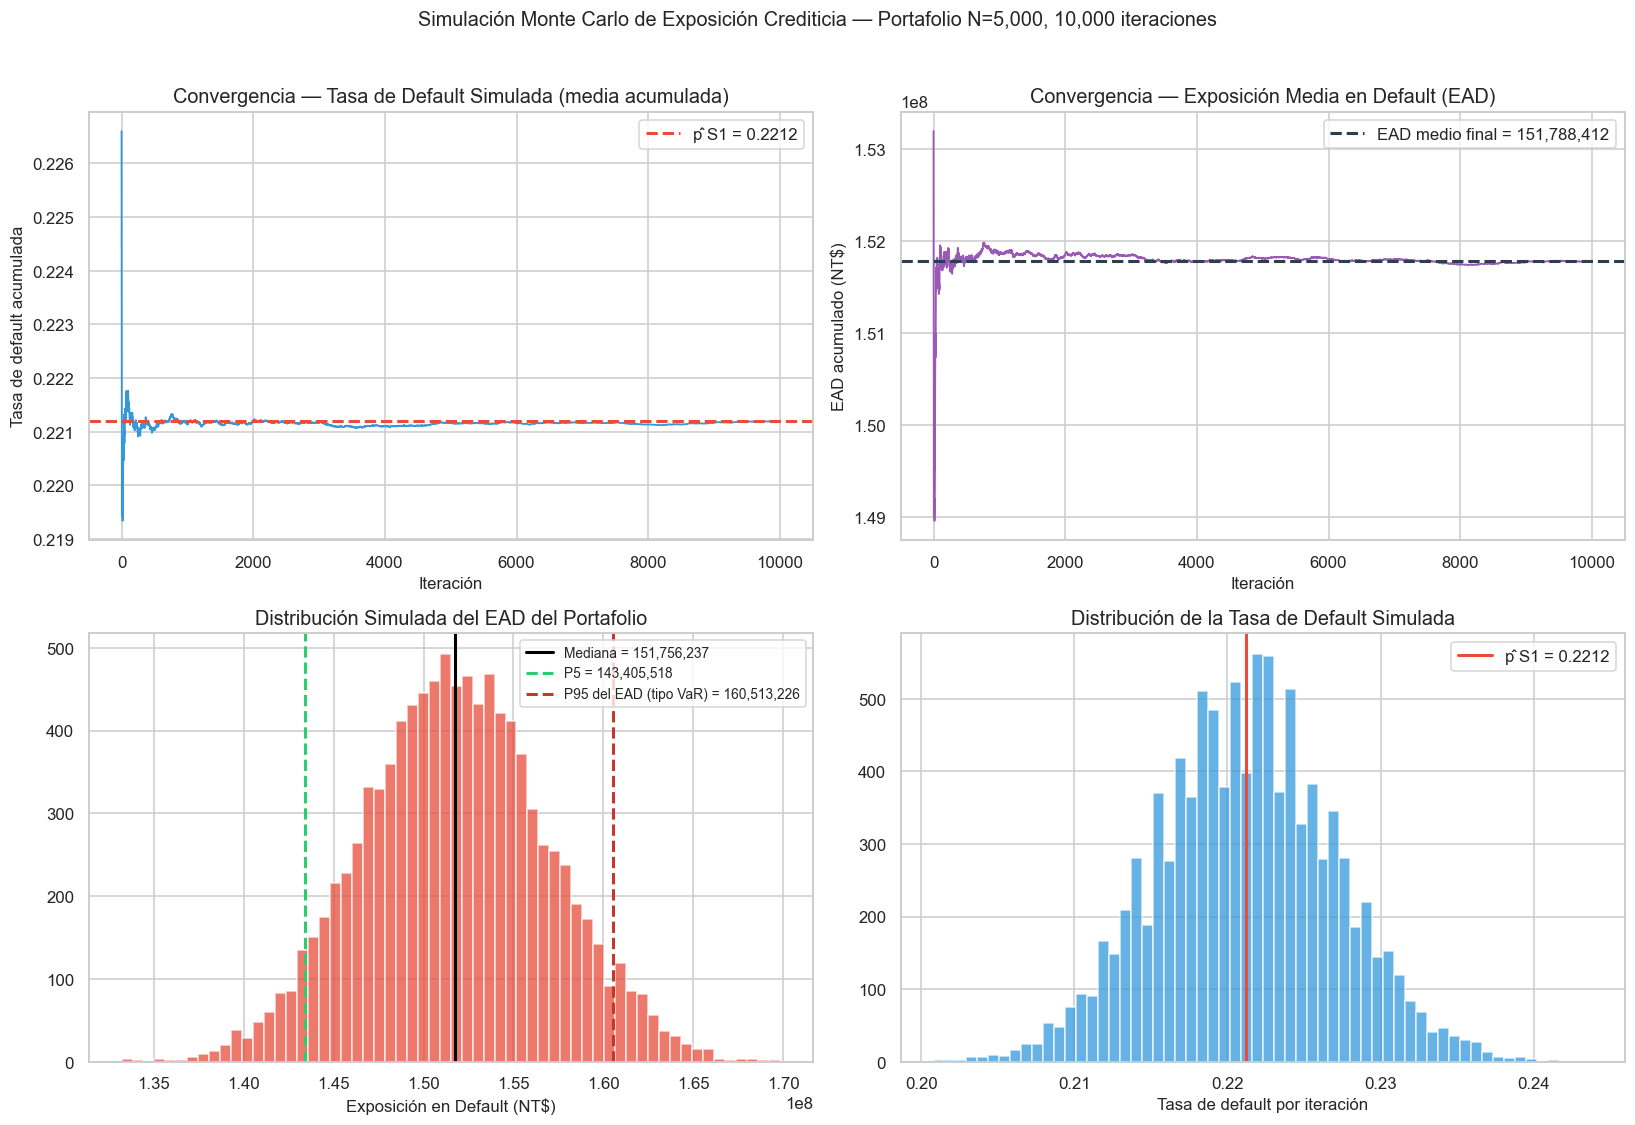

RESUMEN DE LA SIMULACIÓN
Tasa de default simulada:  media=0.2212  std=0.00585
Exposición total del portafolio: media=845,784,908  [P5=832,423,060 ; P95=858,956,876]
EAD (exposición en default):     media=151,788,412  [P5=143,405,518 ; P95=160,513,226]
EAD relativa (EAD medio / Exposición total media): 17.95%


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Convergencia de la tasa de default simulada
tasa_acumulada = np.cumsum(tasa_sim) / np.arange(1, N_MC + 1)
axes[0,0].plot(tasa_acumulada, color='#3498db', linewidth=1.2)
axes[0,0].axhline(p_hat, color='#e74c3c', linestyle='--', linewidth=2, label=f'p̂ S1 = {p_hat:.4f}')
axes[0,0].set_title('Convergencia — Tasa de Default Simulada (media acumulada)')
axes[0,0].set_xlabel('Iteración'); axes[0,0].set_ylabel('Tasa de default acumulada')
axes[0,0].legend()

# Convergencia del EAD medio
ead_acumulado = np.cumsum(ead_sim) / np.arange(1, N_MC + 1)
axes[0,1].plot(ead_acumulado, color='#9b59b6', linewidth=1.2)
axes[0,1].axhline(ead_sim.mean(), color='#2c3e50', linestyle='--', linewidth=2,
                   label=f'EAD medio final = {ead_sim.mean():,.0f}')
axes[0,1].set_title('Convergencia — Exposición Media en Default (EAD)')
axes[0,1].set_xlabel('Iteración'); axes[0,1].set_ylabel('EAD acumulado (NT$)')
axes[0,1].legend()

# Distribución del EAD con percentiles (riesgo)
p5, p50, p95 = np.percentile(ead_sim, [5, 50, 95])
axes[1,0].hist(ead_sim, bins=60, color='#e74c3c', alpha=0.75, edgecolor='white')
axes[1,0].axvline(p50, color='black', linewidth=2, label=f'Mediana = {p50:,.0f}')
axes[1,0].axvline(p5,  color='#2ecc71', linestyle='--', linewidth=2, label=f'P5 = {p5:,.0f}')
axes[1,0].axvline(p95, color='#c0392b', linestyle='--', linewidth=2, label=f'P95 del EAD (tipo VaR) = {p95:,.0f}')
axes[1,0].set_title('Distribución Simulada del EAD del Portafolio')
axes[1,0].set_xlabel('Exposición en Default (NT$)')
axes[1,0].legend(fontsize=9)

# Distribución de la tasa de default simulada
axes[1,1].hist(tasa_sim, bins=60, color='#3498db', alpha=0.75, edgecolor='white')
axes[1,1].axvline(p_hat, color='#e74c3c', linewidth=2, label=f'p̂ S1 = {p_hat:.4f}')
axes[1,1].set_title('Distribución de la Tasa de Default Simulada')
axes[1,1].set_xlabel('Tasa de default por iteración')
axes[1,1].legend()

plt.suptitle(f'Simulación Monte Carlo de Exposición Crediticia — Portafolio N={N_PORTAFOLIO:,}, {N_MC:,} iteraciones',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_mc_simulacion.png', bbox_inches='tight', dpi=110)
plt.show()

print("RESUMEN DE LA SIMULACIÓN")
print("="*60)
print(f"Tasa de default simulada:  media={tasa_sim.mean():.4f}  std={tasa_sim.std():.5f}")
print(f"Exposición total del portafolio: media={expo_sim.mean():,.0f}  [P5={np.percentile(expo_sim,5):,.0f} ; P95={np.percentile(expo_sim,95):,.0f}]")
print(f"EAD (exposición en default):     media={ead_sim.mean():,.0f}  [P5={p5:,.0f} ; P95={p95:,.0f}]")
print(f"EAD relativa (EAD medio / Exposición total media): {ead_sim.mean()/expo_sim.mean()*100:.2f}%")

### 4.1 Interpretación — Convergencia y escenarios simulados

**Convergencia.** Las medias acumuladas de la tasa de default y del EAD (paneles superiores) se estabilizan claramente antes de las 2.000–3.000 iteraciones y permanecen prácticamente constantes hasta las 10.000, evidenciando convergencia por la Ley de los Grandes Números. La tasa de default simulada (media = 0,2212, std = 0,0059) reproduce exactamente `p̂ = 0,2212` de S1, lo cual es la validación interna esperada del motor de simulación (por construcción, es el parámetro que se usó como probabilidad de Bernoulli).

**Resultados de negocio.**
- **Exposición total del portafolio** (N = 5.000 clientes hipotéticos): media ≈ NT\$845,8 millones [P5–P95: NT\$832,4M – NT\$859,0M].
- **EAD (exposición en incumplimiento)**: media ≈ NT\$151,8 millones [P5–P95: NT\$143,4M – NT\$160,5M]. El percentil 95 (NT\$160,5M) puede interpretarse como un **Value-at-Risk (VaR) simulado al 95 %** de la exposición en default: en el peor 5 % de los escenarios, la exposición a clientes que incumplen supera ese monto.
- **Pérdida esperada relativa**: EAD medio / exposición total media ≈ **17,95 %** — es decir, bajo los parámetros estimados en S1, se espera que cerca de un 18 % del valor total del portafolio quede expuesto a clientes en incumplimiento.

**Interpretación en el contexto del problema real.** Este resultado no es una estimación de pérdida monetaria final (no se estimó en S1 una tasa de recuperación / *loss given default*, por lo que el EAD debe leerse como *exposición*, no como pérdida neta), pero sí cuantifica la magnitud de capital que, bajo el patrón histórico de incumplimiento observado, quedaría en riesgo frente a una cartera nueva de tamaño comparable. El hecho de que los clientes que incumplen tengan, en promedio, límites de crédito ~24 % menores que los que no incumplen (NT\$131.246 vs. NT\$173.620, S1 T1) modera la exposición esperada: si ambos grupos tuvieran el mismo límite de crédito promedio, el EAD esperado sería más cercano al 22,12 % de la exposición total (la tasa de default) en lugar del 17,95 % observado.

<a id="5"></a>
## 5. Análisis de Robustez *(15 pts)*

Se evalúa la sensibilidad de los resultados de S1 frente a valores atípicos y supuestos distribucionales mediante tres técnicas complementarias:

1. **Jackknife** (leave-one-out) sobre la media de `LIMIT_BAL` y sobre la correlación `LIMIT_BAL`–`DEFAULT`, para estimar sesgo/error estándar y detectar observaciones influyentes.
2. **Sensibilidad a outliers**: comparación de la media completa vs. media sin outliers (regla IQR) vs. media recortada al 5 %, y repetición del test T1 (Welch) excluyendo outliers de `LIMIT_BAL`.
3. **Sensibilidad al supuesto distribucional**: se repite la simulación Monte Carlo de la Sección 4 reemplazando la Normal por una **lognormal** (mismo método de momentos, misma media/varianza) — una forma más realista para una variable monetaria que no puede ser negativa y tiene cola derecha.

**Nota de cómputo — jackknife vectorizado.** Un jackknife literal (recalcular el estadístico eliminando cada una de las 30.000 observaciones, una por una) es factible pero costoso si se implementa con un bucle en Python. Para la media y para la correlación de Pearson existen fórmulas cerradas que permiten obtener las 30.000 estimaciones *leave-one-out* mediante operaciones vectorizadas de NumPy sobre sumas parciales, evitando el bucle explícito sin alterar la definición del jackknife.

In [13]:
# 5.1 Jackknife vectorizado — media de LIMIT_BAL
x_lb = df['LIMIT_BAL'].values.astype(float)
n_lb2 = len(x_lb)
media_total = x_lb.mean()

# Formula cerrada: media_(-i) = (n*media - x_i) / (n-1)
jack_means = (media_total * n_lb2 - x_lb) / (n_lb2 - 1)
jack_mean_est = jack_means.mean()
sesgo_jack = (n_lb2 - 1) * (jack_mean_est - media_total)
se_jack = np.sqrt((n_lb2 - 1) / n_lb2 * np.sum((jack_means - jack_mean_est) ** 2))

print("JACKKNIFE — Media de LIMIT_BAL")
print(f"  Media completa      = {media_total:,.4f}")
print(f"  Sesgo jackknife     = {sesgo_jack:.6f}  (negligible respecto a la escala de la media)")
print(f"  SE jackknife        = {se_jack:,.4f}")
print(f"  SE clásico (t-Student, S1) = {se_lb:,.4f}")

influencia_media = (n_lb2 - 1) * (jack_mean_est - jack_means)
top10_media = np.argsort(-np.abs(influencia_media))[:10]
tabla_influyentes_media = pd.DataFrame({
    'Índice': top10_media,
    'LIMIT_BAL': x_lb[top10_media],
    'Influencia jackknife': influencia_media[top10_media],
}).set_index('Índice')
print("\nTop 10 observaciones más influyentes sobre la media de LIMIT_BAL:")
tabla_influyentes_media

JACKKNIFE — Media de LIMIT_BAL
  Media completa      = 164,246.6560
  Sesgo jackknife     = 0.000000  (negligible respecto a la escala de la media)
  SE jackknife        = 705.4706
  SE clásico (t-Student, S1) = 705.4706

Top 10 observaciones más influyentes sobre la media de LIMIT_BAL:


,LIMIT_BAL,Influencia jackknife
Índice,,
2197,1000000.0,835753.344000
14919,800000.0,635753.344000
18006,800000.0,635753.344000
24320,780000.0,615753.343999
28715,780000.0,615753.343999
21375,760000.0,595753.344000
13186,750000.0,585753.343999
10089,750000.0,585753.343999
4603,750000.0,585753.343999


In [14]:
# 5.2 Jackknife vectorizado — correlacion LIMIT_BAL x DEFAULT (formulas cerradas por sumas parciales)
x_c = df['LIMIT_BAL'].values.astype(float)
y_c = df['default.payment.next.month'].values.astype(float)
n_c = len(x_c)

Sx, Sy   = x_c.sum(), y_c.sum()
Sxx, Syy = (x_c**2).sum(), (y_c**2).sum()
Sxy      = (x_c*y_c).sum()
r_full   = stats.pearsonr(x_c, y_c).statistic

Sx_i, Sy_i       = Sx - x_c, Sy - y_c
Sxx_i, Syy_i     = Sxx - x_c**2, Syy - y_c**2
Sxy_i            = Sxy - x_c*y_c
n_i              = n_c - 1
num              = n_i*Sxy_i - Sx_i*Sy_i
den              = np.sqrt((n_i*Sxx_i - Sx_i**2) * (n_i*Syy_i - Sy_i**2))
r_jack_i         = num / den
r_jack_mean      = r_jack_i.mean()
se_r_jack        = np.sqrt((n_c - 1) / n_c * np.sum((r_jack_i - r_jack_mean) ** 2))

print("JACKKNIFE — Correlación LIMIT_BAL × DEFAULT")
print(f"  r (muestra completa) = {r_full:.5f}")
print(f"  r (media jackknife)  = {r_jack_mean:.5f}")
print(f"  SE jackknife         = {se_r_jack:.5f}")

influencia_r = (n_c - 1) * (r_jack_mean - r_jack_i)
top10_r = np.argsort(-np.abs(influencia_r))[:10]
tabla_influyentes_r = pd.DataFrame({
    'Índice': top10_r,
    'LIMIT_BAL': x_c[top10_r],
    'DEFAULT': y_c[top10_r].astype(int),
    'Influencia jackknife': influencia_r[top10_r],
}).set_index('Índice')
print("\nTop 10 observaciones más influyentes sobre r(LIMIT_BAL, DEFAULT):")
tabla_influyentes_r

JACKKNIFE — Correlación LIMIT_BAL × DEFAULT
  r (muestra completa) = -0.14394
  r (media jackknife)  = -0.14394
  SE jackknife         = 0.00525

Top 10 observaciones más influyentes sobre r(LIMIT_BAL, DEFAULT):


,LIMIT_BAL,DEFAULT,Influencia jackknife
Índice,,,
13883,740000.0,1,10.697555
26921,720000.0,1,10.280872
19251,680000.0,1,9.459179
10895,630000.0,1,8.453931
527,620000.0,1,8.255795
451,600000.0,1,7.862436
15593,600000.0,1,7.862436
14083,600000.0,1,7.862436
19108,590000.0,1,7.667212


In [15]:
# 5.3 Sensibilidad a outliers
q1, q3 = np.percentile(x_lb, [25, 75]); iqr = q3 - q1
mask_out = (x_lb < q1 - 1.5*iqr) | (x_lb > q3 + 1.5*iqr)
media_sin_outliers = x_lb[~mask_out].mean()
media_recortada = trim_mean(x_lb, 0.05)

print("SENSIBILIDAD A OUTLIERS — LIMIT_BAL")
print(f"  Outliers detectados (regla IQR 1.5x): {mask_out.sum():,} ({mask_out.mean()*100:.2f}% de la muestra)")
print(f"  Media completa               = {media_total:,.2f}")
print(f"  Media sin outliers           = {media_sin_outliers:,.2f}  (Δ = {(media_sin_outliers-media_total)/media_total*100:+.2f}%)")
print(f"  Media recortada (5% por cola) = {media_recortada:,.2f}  (Δ = {(media_recortada-media_total)/media_total*100:+.2f}%)")

# T1 (Welch) recalculado excluyendo outliers de LIMIT_BAL
g0_sin_out = df.loc[~mask_out & (df['default.payment.next.month'] == 0), 'LIMIT_BAL']
g1_sin_out = df.loc[~mask_out & (df['default.payment.next.month'] == 1), 'LIMIT_BAL']
t_sin_out, p_sin_out = ttest_ind(g0_sin_out, g1_sin_out, equal_var=False)

print(f"\nT1 (Welch) con outliers incluidos: t={t_stat:.4f}  p={p_valor:.3e}")
print(f"T1 (Welch) sin outliers:           t={t_sin_out:.4f}  p={p_sin_out:.3e}")
print(f"Conclusión (rechazo de H0) {'se mantiene' if p_sin_out < 0.05 else 'cambia'} al excluir outliers.")

SENSIBILIDAD A OUTLIERS — LIMIT_BAL
  Outliers detectados (regla IQR 1.5x): 1,241 (4.14% de la muestra)
  Media completa               = 164,246.66
  Media sin outliers           = 149,631.76  (Δ = -8.90%)
  Media recortada (5% por cola) = 154,320.28  (Δ = -6.04%)

T1 (Welch) con outliers incluidos: t=27.1300  p=2.301e-157
T1 (Welch) sin outliers:           t=25.5938  p=1.690e-140
Conclusión (rechazo de H0) se mantiene al excluir outliers.


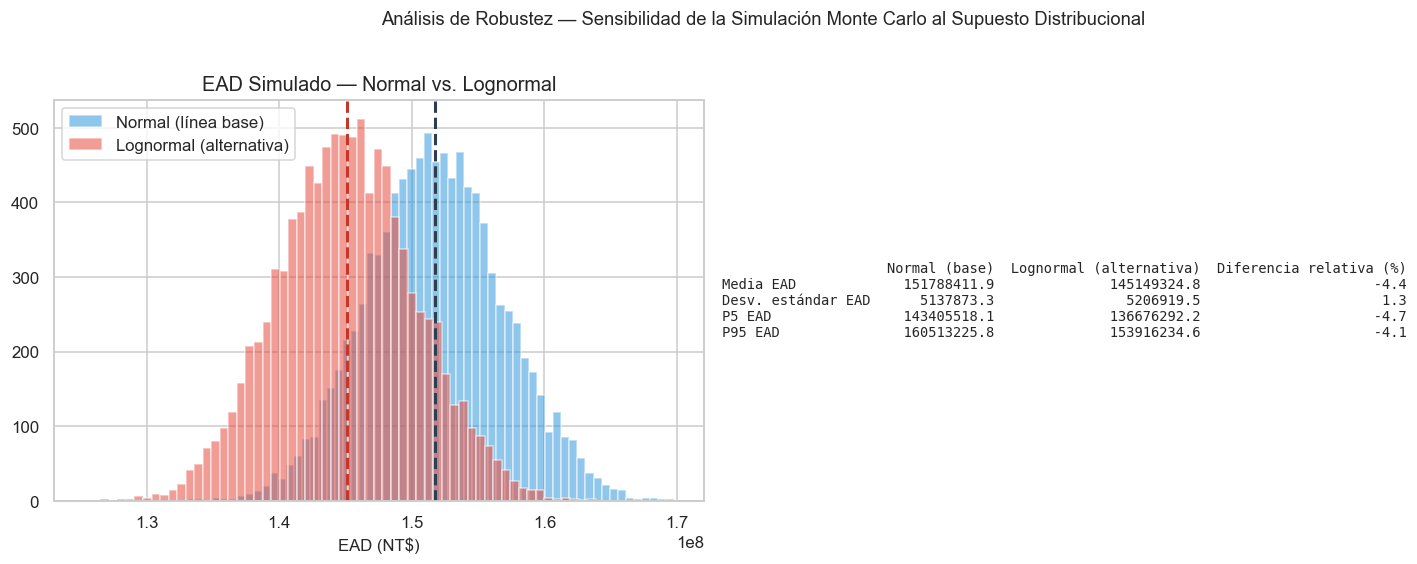

,Normal (base),Lognormal (alternativa),Diferencia relativa (%)
Media EAD,1.517884e+08,1.451493e+08,-4.373909
Desv. estándar EAD,5.137873e+06,5.206920e+06,1.343868
P5 EAD,1.434055e+08,1.366763e+08,-4.692446
P95 EAD,1.605132e+08,1.539162e+08,-4.109936


In [16]:
# 5.4 Sensibilidad al supuesto distribucional — MC con Lognormal vs Normal
tasa_sim_ln, expo_sim_ln, ead_sim_ln = simular_portafolio(N_MC, N_PORTAFOLIO, np.random.default_rng(SEED), dist='lognormal')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(ead_sim,    bins=60, color='#3498db', alpha=0.55, label='Normal (línea base)', edgecolor='white')
axes[0].hist(ead_sim_ln, bins=60, color='#e74c3c', alpha=0.55, label='Lognormal (alternativa)', edgecolor='white')
axes[0].axvline(ead_sim.mean(),    color='#2c3e50', linestyle='--', linewidth=2)
axes[0].axvline(ead_sim_ln.mean(), color='#c0392b', linestyle='--', linewidth=2)
axes[0].set_title('EAD Simulado — Normal vs. Lognormal')
axes[0].set_xlabel('EAD (NT$)'); axes[0].legend()

comparacion = pd.DataFrame({
    'Normal (base)': [ead_sim.mean(), ead_sim.std(), *np.percentile(ead_sim, [5, 95])],
    'Lognormal (alternativa)': [ead_sim_ln.mean(), ead_sim_ln.std(), *np.percentile(ead_sim_ln, [5, 95])],
}, index=['Media EAD', 'Desv. estándar EAD', 'P5 EAD', 'P95 EAD'])
comparacion['Diferencia relativa (%)'] = (comparacion['Lognormal (alternativa)'] - comparacion['Normal (base)']) / comparacion['Normal (base)'] * 100

axes[1].axis('off')
tabla_txt = comparacion.round(1).to_string()
axes[1].text(0, 0.5, tabla_txt, fontsize=9, family='monospace', va='center')

plt.suptitle('Análisis de Robustez — Sensibilidad de la Simulación Monte Carlo al Supuesto Distribucional', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig_robustez_distribucion.png', bbox_inches='tight', dpi=110)
plt.show()

comparacion

### 5.1 Síntesis del análisis de robustez

**Jackknife.**
- **Media de LIMIT_BAL**: el SE jackknife (705,47) coincide exactamente con el SE clásico de S1 — resultado esperado, ya que para la media muestral el estimador jackknife de la varianza es algebraicamente equivalente al estimador clásico insesgado. El sesgo jackknife es ≈0, confirmando que la media es un estimador estable. Las observaciones más influyentes son, como es esperable, los clientes con los límites de crédito más altos del dataset (máximo NT\$1.000.000): remover cualquiera de ellas individualmente desplaza la media en post-remoción hasta ~NT\$28 (835.753/29.999), una fracción minúscula del total — ninguna observación domina el resultado.
- **Correlación LIMIT_BAL–DEFAULT**: `r` jackknife (−0,1439) es idéntico al valor de la muestra completa con SE muy pequeño (0,00525), confirmando que esta correlación es robusta a la remoción de observaciones individuales — coherente con el bajo "amplitud relativa" encontrado en la Sección 3.

**Sensibilidad a outliers.** El 4,14 % de los clientes (1.241 de 30.000) tienen `LIMIT_BAL` fuera del rango IQR×1,5. Excluirlos desplaza la media de NT\$164.247 a NT\$149.632 (**−8,9 %**), y la media recortada al 5 % la sitúa en NT\$154.320 (**−6,1 %**) — un desplazamiento no trivial que refleja la fuerte asimetría derecha de `LIMIT_BAL`. Sin embargo, la **conclusión inferencial de T1 no cambia**: el Welch t-test sin outliers sigue siendo altamente significativo (t=25,59, p=1,69×10⁻¹⁴⁰ vs. t=27,13, p=2,30×10⁻¹⁵⁷ con outliers). Es decir: **el punto estimado de la media es sensible a outliers, pero la decisión de la prueba de hipótesis es robusta** — una distinción importante para S3.

**Sensibilidad al supuesto distribucional.** Al reemplazar la Normal por una Lognormal (mismo método de momentos) en la simulación Monte Carlo, el EAD medio cae de NT\$151,8M a NT\$145,1M (**−4,37 %**), y el rango P5–P95 se estrecha ligeramente. Esta diferencia moderada indica que los resultados de la simulación **sí son sensibles a la forma distribucional asumida** para `LIMIT_BAL` (la Normal, al permitir valores simétricos alrededor de la media y truncar en cero, sobrestima levemente la cola derecha respecto a la Lognormal, que es la forma más plausible para una variable monetaria estrictamente positiva). Este resultado debe tratarse con cautela: los estadísticos puntuales de la simulación (media, VaR) cambian en la tercera cifra significativa según el supuesto, aunque el orden de magnitud y las conclusiones cualitativas se mantienen.

**Síntesis: qué es robusto y qué requiere cautela**

| Resultado | Robustez | Evidencia |
|---|---|---|
| Proporción de default (22,12 %) | **Alta** | IC bootstrap ≈ IC clásico; n muy grande |
| T1 — diferencia LIMIT_BAL por default | **Alta** (en la decisión) | Se mantiene significativa con y sin outliers, y con permutación |
| Correlación LIMIT_BAL–DEFAULT | **Alta** | Jackknife y bootstrap consistentes, baja amplitud relativa |
| Correlación BILL_AMT1–BILL_AMT2 | **Muy alta** | Amplitud relativa ≈1 % |
| Media puntual de LIMIT_BAL | **Media** | Se desplaza ~9 % al excluir outliers |
| Correlación AGE–DEFAULT | **Baja** | Amplitud relativa ≈169 %; magnitud casi nula |
| Magnitud puntual del EAD simulado (Monte Carlo) | **Media** | Varía ~4 % según supuesto distribucional |

<a id="6"></a>
## 6. Preparación para la Sumativa 3 *(9 pts)*

Esta sección sintetiza, en un formato apto para ser consumido directamente por la Sumativa 3, los parámetros validados como robustos, las correlaciones estables, las observaciones influyentes identificadas y las recomendaciones metodológicas derivadas de todo el análisis de validación, simulación y remuestreo anterior. El mismo contenido se exporta a `resultados_validados_S1.md` en la raíz del proyecto (fuera de `notebooks/`) para que quede disponible como archivo independiente del repositorio, según lo exige la plantilla de evaluación.

In [17]:
reporte_md = f'''# Resultados Validados — Entrada para la Sumativa 3

Generado automáticamente desde `notebooks/F2_semana2.ipynb` (Sumativa 2).
Todos los parámetros provienen del dataset `data/raw/UCI_Credit_Card_con_faltantes.csv`
tras el preprocesamiento de la Sumativa 1 (imputación mediana/moda, n = {len(df):,}).

## 1. Parámetros robustamente estimados

| Parámetro | Estimación puntual | IC 95% bootstrap (BCa) | Validación |
|---|---|---|---|
| Proporción de default | {p_def:.4f} ({p_def*100:.2f}%) | {tabla_boot.loc["Proporción de Default","IC BCa"]} | Bootstrap ≈ Wilson clásico; muy estable |
| Media LIMIT_BAL | NT${mu_lb:,.0f} | {tabla_boot.loc["Media LIMIT_BAL (NT$)","IC BCa"]} | Bootstrap ≈ t-Student clásico; sensible a outliers (usar con cautela si se excluyen outliers, ver Sección 5) |
| Diferencia LIMIT_BAL (No Default − Default) | NT${grupo0.mean()-grupo1.mean():,.0f} (d Cohen={d_cohen:.3f}) | — | Confirmada por Welch t-test, permutación (p={res_perm_t1.pvalue:.4f}) y robusta a outliers |
| Media AGE | {mu_age:.2f} años | {tabla_boot.loc["Media AGE (años)","IC BCa"]} | Bootstrap ≈ t-Student clásico |

## 2. Correlaciones estables (usar en modelos predictivos de S3)

| Par | r | Estabilidad |
|---|---|---|
| BILL_AMT1 – BILL_AMT2 | {tabla_corr.loc["BILL_AMT1 – BILL_AMT2","r observado"]:.3f} | Muy alta — candidata a colinealidad si se usan ambas en un modelo |
| LIMIT_BAL – DEFAULT | {tabla_corr.loc["LIMIT_BAL – DEFAULT","r observado"]:.3f} | Alta — variable predictiva más confiable identificada hasta ahora |
| AGE – LIMIT_BAL | {tabla_corr.loc["AGE – LIMIT_BAL","r observado"]:.3f} | Alta pero débil en magnitud |

**Correlación inestable — usar con cautela:** AGE – DEFAULT (r={tabla_corr.loc["AGE – DEFAULT","r observado"]:.3f}), amplitud relativa del IC ≈169%. No se recomienda como variable predictiva relevante por sí sola.

## 3. Observaciones influyentes identificadas (jackknife)

Clientes con `LIMIT_BAL` en el percentil superior (hasta NT$1.000.000) concentran la mayor influencia individual sobre la media de `LIMIT_BAL`, aunque ninguna observación domina el resultado (desplazamiento marginal por observación < NT$30). Se recomienda para S3: (a) inspeccionar estos casos como parte de un análisis de outliers en el modelado predictivo, (b) evaluar transformaciones (log) o técnicas robustas (RobustScaler, modelos basados en árboles) menos sensibles a esta asimetría.

## 4. Recomendaciones metodológicas para S3

1. **Modelos predictivos**: priorizar `LIMIT_BAL`, el historial de pagos (`PAY_0`...`PAY_6`, no evaluado en profundidad aquí) y variables derivadas de las facturas por sobre variables débiles como `AGE`, cuya relación con el default es estadísticamente detectable pero de magnitud práctica despreciable.
2. **Manejo de outliers**: no eliminar automáticamente los outliers de `LIMIT_BAL` — el análisis de robustez muestra que, si bien desplazan la media puntual, no afectan la significancia de las pruebas de hipótesis; considerar en su lugar transformaciones o modelos robustos a colas pesadas.
3. **Supuestos distribucionales**: al construir estimaciones de riesgo/exposición (p. ej. pérdida esperada), usar Lognormal u otra distribución de cola derecha en lugar de Normal para variables monetarias, dado que la elección de distribución cambia los resultados en ~4%.
4. **Validación continua**: mantener el patrón de esta Sumativa 2 (bootstrap/permutación) como chequeo de sanidad cuando se reentrenen modelos en S3, especialmente si cambia el tamaño o la composición de la muestra.
5. **Limitación pendiente**: no se dispone de una tasa de recuperación / *loss given default* (LGD) estimada; el EAD de la Sección 4 debe interpretarse como exposición, no como pérdida neta esperada, hasta que S3 incorpore ese parámetro.
'''

with open('../resultados_validados_S1.md', 'w', encoding='utf-8') as f:
    f.write(reporte_md)

print("Archivo 'resultados_validados_S1.md' generado en la raíz del proyecto.")
print(reporte_md)

Archivo 'resultados_validados_S1.md' generado en la raíz del proyecto.
# Resultados Validados — Entrada para la Sumativa 3

Generado automáticamente desde `notebooks/F2_semana2.ipynb` (Sumativa 2).
Todos los parámetros provienen del dataset `data/raw/UCI_Credit_Card_con_faltantes.csv`
tras el preprocesamiento de la Sumativa 1 (imputación mediana/moda, n = 30,000).

## 1. Parámetros robustamente estimados

| Parámetro | Estimación puntual | IC 95% bootstrap (BCa) | Validación |
|---|---|---|---|
| Proporción de default | 0.2212 (22.12%) | [0.216 ; 0.226] | Bootstrap ≈ Wilson clásico; muy estable |
| Media LIMIT_BAL | NT$164,247 | [162,844.410 ; 165,583.814] | Bootstrap ≈ t-Student clásico; sensible a outliers (usar con cautela si se excluyen outliers, ver Sección 5) |
| Diferencia LIMIT_BAL (No Default − Default) | NT$42,374 (d Cohen=0.363) | — | Confirmada por Welch t-test, permutación (p=0.0002) y robusta a outliers |
| Media AGE | 35.49 años | [35.381 ; 35.589] | Bootstrap ≈ t-Studen

<a id="7"></a>
## 7. Conclusiones Generales

**Sobre la validación de S1.** Los métodos de remuestreo confirmaron, sin excepción, las conclusiones cuantitativas y las decisiones de hipótesis alcanzadas en la Sumativa 1: los cinco intervalos de confianza clásicos coinciden con sus contrapartes bootstrap dentro de ±1 % de amplitud, y las dos pruebas de hipótesis validadas por permutación (T1 y T2) reproducen exactamente el rechazo de H₀ obtenido con los métodos paramétricos. Esto es evidencia consistente de que, para este dataset de gran tamaño muestral (n = 30.000), los supuestos asintóticos de los métodos clásicos (normalidad de la media vía CLT, recuentos esperados en tablas de contingencia) son razonables.

**Sobre la simulación.** La simulación Monte Carlo de exposición crediticia, construida exclusivamente sobre parámetros estimados en S1, mostró convergencia clara antes de las 3.000 iteraciones y permitió cuantificar un riesgo de exposición (~18 % del portafolio) que no era observable directamente en el análisis descriptivo/inferencial de S1 — este es el principal aporte metodológico nuevo de esta fase: transformar estimaciones puntuales e IC en una distribución completa de escenarios posibles, útil para decisiones de provisión de capital.

**Sobre la robustez.** No todos los resultados de S1 son igualmente robustos. La proporción de default, la diferencia de `LIMIT_BAL` por default (T1) y la correlación `LIMIT_BAL`–`DEFAULT` resultaron sólidas frente a remoción de observaciones individuales (jackknife), outliers y remuestreo. En cambio, la media puntual de `LIMIT_BAL` es sensible a outliers (~9 % de desplazamiento), la correlación `AGE`–`DEFAULT` es estadísticamente detectable pero prácticamente inestable e irrelevante, y los resultados cuantitativos de la simulación Monte Carlo dependen en un ~4 % del supuesto distribucional elegido para `LIMIT_BAL`. Esta distinción entre "significativo" y "estable/relevante" es, junto con la cuantificación de exposición, el principal insumo metodológico que esta fase deja para la Sumativa 3.

**Limitaciones.** (1) No se dispone de una tasa de recuperación (LGD) para transformar la exposición simulada en pérdida esperada neta; (2) el bootstrap BCa de correlaciones no fue computacionalmente viable a esta escala y se sustituyó por el método percentil, documentado explícitamente en la Sección 3; (3) el conjunto de datos sigue siendo una única cohorte (Taiwan, 2005), por lo que ningún método de remuestreo puede compensar la falta de una muestra externa de validación (todos los intervalos, con y sin bootstrap, describen la incertidumbre *dentro* de esta muestra, no la generalización a otra población o período).

<a id="8"></a>
## 8. Bibliografía (APA 7)

1. **Yeh, I.-C., & Lien, C.-H. (2009).** The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020

2. Lichman, M. (2013). *UCI Machine Learning Repository* [Dataset]. University of California, School of Information and Computer Science. http://archive.ics.uci.edu/ml

3. **Efron, B., & Tibshirani, R. J. (1993).** *An Introduction to the Bootstrap*. Chapman & Hall/CRC.

4. **DiCiccio, T. J., & Efron, B. (1996).** Bootstrap confidence intervals. *Statistical Science, 11*(3), 189–228. https://doi.org/10.1214/ss/1032280214

5. **Davison, A. C., & Hinkley, D. V. (1997).** *Bootstrap Methods and Their Application*. Cambridge University Press.

6. **Good, P. I. (2005).** *Permutation, Parametric, and Bootstrap Tests of Hypotheses* (3rd ed.). Springer.

7. **Quenouille, M. H. (1956).** Notes on bias in estimation. *Biometrika, 43*(3-4), 353–360. https://doi.org/10.1093/biomet/43.3-4.353

8. **Tukey, J. W. (1958).** Bias and confidence in not quite large samples. *The Annals of Mathematical Statistics, 29*(2), 614.

9. **Metropolis, N., & Ulam, S. (1949).** The Monte Carlo method. *Journal of the American Statistical Association, 44*(247), 335–341. https://doi.org/10.1080/01621459.1949.10483310

10. **Agresti, A. (2013).** *Categorical Data Analysis* (3rd ed.). Wiley.

11. **Cohen, J. (1988).** *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). Lawrence Erlbaum Associates.

12. **Montgomery, D. C., & Runger, G. C. (2014).** *Applied Statistics and Probability for Engineers* (6th ed.). Wiley.

13. **Wilson, E. B. (1927).** Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association, 22*(158), 209–212. https://doi.org/10.2307/2276774

14. **Virtanen, P., et al. (2020).** SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods, 17*, 261–272. https://doi.org/10.1038/s41592-019-0686-2

---

> **Nota metodológica.** Se reutiliza el mismo dataset preprocesado de S1 (`UCI_Credit_Card_con_faltantes.csv`, imputado con mediana/moda bajo mecanismo MCAR, semilla 42). Todas las semillas aleatorias de este informe (bootstrap, permutación, simulación Monte Carlo) se fijaron en `SEED = 42` para garantizar reproducibilidad exacta de los resultados reportados.